In [1]:
import os, pickle
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB'                       # or Demand

surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A2_smooth_decomposition', dataset_name)

PKL_output = os.path.join(resultsPath, 'output.pkl')
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

In [4]:
PKL_vis_output = os.path.join(resultsPath, 'vis_output.pkl')
vis_output = {}

In [5]:
smooth_kernels = list(output.keys())
ROIs = list(output['orig_mm'].keys())

v_s_over_gs = {}

for roi in ROIs:
    v_s_over_gs[roi] = []
    
    for smooth_kernel in smooth_kernels:
        v_s_over_gs[roi].append(output[smooth_kernel][roi][0, 1] / (output[smooth_kernel][roi][0, 0] + output[smooth_kernel][roi][0, 1]))

    v_s_over_gs[roi] = np.array(v_s_over_gs[roi])

vis_output['v_s_over_gs'] = v_s_over_gs

In [6]:
v_s_over_gs

{'PFC': array([0.76425358, 0.60295894, 0.94002325, 0.98343956, 0.99464692,
        0.99912081, 0.99951846]),
 'parietal': array([0.60670826, 0.38435648, 0.90488245, 0.97752942, 0.99195549,
        0.99848585, 0.99978376]),
 'visual': array([0.44675973, 0.24347406, 0.85189008, 0.9545787 , 0.9821388 ,
        0.99649202, 0.99663052]),
 'somatosensory': array([0.63274309, 0.42735791, 0.77357649, 0.92564218, 0.97183629,
        0.99052413, 0.99453348])}

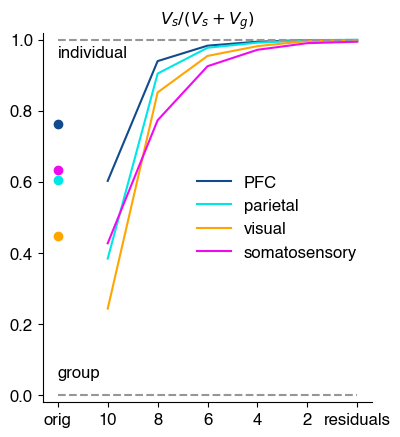

In [7]:
colors = [(18/255, 75/255, 141/255), (0, 230/255, 230/255), (255/255, 165/255, 0/255), (240/255, 10/255, 240/255)]

fig, ax = plt.subplots()
fig.set_figwidth(half_width) 

for roiI in np.arange(len(ROIs)):
    ax.scatter(0, v_s_over_gs[ROIs[roiI]][0], color=colors[roiI], marker='o')
    ax.plot(np.arange(1, len(smooth_kernels)), v_s_over_gs[ROIs[roiI]][1:], color=colors[roiI], linestyle='-', label=ROIs[roiI])

ax.hlines(0, xmin=0, xmax=len(smooth_kernels)-1, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.hlines(1, xmin=0, xmax=len(smooth_kernels)-1, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.text(0, 0.05, 'group')
ax.text(0, 0.95, 'individual')

xlabels = [l.strip('_mm') for l in smooth_kernels]

ax.set_xticks(np.arange(len(smooth_kernels)), xlabels)
ax.set_title('$V_s/(V_s+V_g)$', fontsize=12)

ax.legend(frameon=False, loc='right')
ax.set_ylim([-0.02, 1.02])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(resultsPath, f'vs_over_gs.jpg'), dpi=500, format='jpeg')

with open(PKL_vis_output, 'wb') as pk:
    pickle.dump(vis_output, pk)

plt.show()